<a href="https://colab.research.google.com/github/MartinaEkya/Tugas_KKA/blob/main/Tugas_Kelompok%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama Anggota Kelompok:
1. Intan Arum Nuraini (12)
2. Martina Ekya Rahmat (17)

Dataset yang Dipilih: Data Nilai Akademik Siswa
Pertanyaan Analisis Awal

1. Mata pelajaran apa yang rata-rata nilainya paling rendah?
2. Berapa persentase siswa yang nilainya di bawah KKM (75)?
3. Apakah ada perbedaan rata-rata nilai antar kelas (XI RPL 1, 2, 3)?

Dugaan Masalah Kualitas Data:
* Missing value pada kolom: nilai, guru_pengampu
* Duplikat data
* Tipe data tidak sesuai pada kolom: nilai (ada teks "poin"), tanggal_ujian (3 format berbeda), jenis_ujian (huruf besar/kecil tidak konsisten)
* Lainnya: ada nilai tidak masuk akal (999)

Rencana Teknik Pembersihan:
Bersihkan teks "poin" pada nilai, ubah ke numerik, nilai di luar 0–100 dianggap invalid lalu diisi median per mata pelajaran. guru_pengampu kosong diisi "Tidak Diketahui". Duplikat dihapus. Tanggal & jenis ujian diseragamkan formatnya.

Rencana Manipulasi Data	Filter:
siswa Remedial (nilai < 75)
Sort: nilai tertinggi ke terendah
Kolom turunan: status (Lulus/Remedial)
Groupby: rata-rata nilai per mata pelajaran & per kelas

Jadwal Kerja:
P3: Loading & Inspection
P4: Cleaning
P5: Manipulation
P6: Uji & Presentasi

Pembagian Peran:
Anggota 1: Cleaning & Inspection
Anggota 2: Manipulation & ringkasan temuan

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('dataset_akademik_siswa.csv')
df.head()
df.info()
df.describe(include='all')
print("Jumlah baris, kolom:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_siswa        79 non-null     object
 1   nama            79 non-null     object
 2   kelas           79 non-null     object
 3   mata_pelajaran  79 non-null     object
 4   jenis_ujian     79 non-null     object
 5   tanggal_ujian   79 non-null     object
 6   nilai           75 non-null     object
 7   guru_pengampu   75 non-null     object
dtypes: object(8)
memory usage: 5.1+ KB
Jumlah baris, kolom: (79, 8)


In [ ]:
print("Jumlah data kosong tiap kolom:")
print(df.isnull().sum())
print("\nJumlah baris duplikat:", df.duplicated().sum())

Jumlah data kosong tiap kolom:
id_siswa          0
nama              0
kelas             0
mata_pelajaran    0
jenis_ujian       0
tanggal_ujian     0
nilai             4
guru_pengampu     4
dtype: int64

Jumlah baris duplikat: 4


In [ ]:
df['nilai'] = df['nilai'].astype(str).str.replace(' poin', '', regex=False)
df['nilai'] = pd.to_numeric(df['nilai'], errors='coerce')

df.loc[(df['nilai'] < 0) | (df['nilai'] > 100), 'nilai'] = np.nan
print("Nilai kosong/invalid:", df['nilai'].isnull().sum())

df['nilai'] = df.groupby('mata_pelajaran')['nilai'].transform(lambda x: x.fillna(x.median()))
df['nilai'] = df['nilai'].astype(float).round(1)
df.info()

Nilai kosong/invalid: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_siswa        79 non-null     object 
 1   nama            79 non-null     object 
 2   kelas           79 non-null     object 
 3   mata_pelajaran  79 non-null     object 
 4   jenis_ujian     79 non-null     object 
 5   tanggal_ujian   79 non-null     object 
 6   nilai           79 non-null     float64
 7   guru_pengampu   75 non-null     object 
dtypes: float64(1), object(7)
memory usage: 5.1+ KB


In [ ]:
df['guru_pengampu'] = df['guru_pengampu'].fillna('Tidak Diketahui')
print("Sebelum drop_duplicates:", len(df))
df = df.drop_duplicates()
print("Setelah drop_duplicates:", len(df))

df['jenis_ujian'] = df['jenis_ujian'].str.upper()
print(df['jenis_ujian'].unique())
df.info()

Sebelum drop_duplicates: 79
Setelah drop_duplicates: 75
['UAS' 'UTS' 'UH']
<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 0 to 78
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_siswa        75 non-null     object 
 1   nama            75 non-null     object 
 2   kelas           75 non-null     object 
 3   mata_pelajaran  75 non-null     object 
 4   jenis_ujian     75 non-null     object 
 5   tanggal_ujian   75 non-null     object 
 6   nilai           75 non-null     float64
 7   guru_pengampu   75 non-null     object 
dtypes: float64(1), object(7)
memory usage: 5.3+ KB


In [ ]:
import pandas as pd

bulan_map = {
    'Januari': 'January', 'Februari': 'February', 'Maret': 'March',
    'April': 'April', 'Mei': 'May', 'Juni': 'June',
    'Juli': 'July', 'Agustus': 'August', 'September': 'September',
    'Oktober': 'October', 'November': 'November', 'Desember': 'December'
}

def id_ke_en(teks):
    if not isinstance(teks, str):
        return teks
    for id_bulan, en_bulan in bulan_map.items():
        teks = teks.replace(id_bulan, en_bulan)
    return teks

def parse_tanggal(teks):
    if pd.isna(teks):
        return pd.NaT

    if not isinstance(teks, str):
        teks = str(teks)

    teks = id_ke_en(teks)

    for fmt in ('%d/%m/%Y', '%Y-%m-%d', '%d %B %Y'):
        try:
            return pd.to_datetime(teks, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df['tanggal_ujian'] = df['tanggal_ujian'].apply(parse_tanggal)
print("Tanggal gagal diparse:", df['tanggal_ujian'].isnull().sum())
print(df.dtypes)

Tanggal gagal diparse: 0
id_siswa                  object
nama                      object
kelas                     object
mata_pelajaran            object
jenis_ujian               object
tanggal_ujian     datetime64[ns]
nilai                    float64
guru_pengampu             object
dtype: object


In [ ]:
KKM = 75
df['status'] = np.where(df['nilai'] >= KKM, 'Lulus', 'Remedial')
df[['nama', 'mata_pelajaran', 'nilai', 'status']].head()
# Filtering
remedial = df[df['status'] == 'Remedial']
print(f"Jumlah siswa remedial: {len(remedial)} dari {len(df)} ({len(remedial)/len(df):.1%})")
# Sorting
urut = df.sort_values(by='nilai', ascending=False)
urut[['nama', 'mata_pelajaran', 'kelas', 'nilai']].head(10)
# Groupby / Agregasi
rata_per_mapel = df.groupby('mata_pelajaran')['nilai'].mean().sort_values(ascending=False).round(1)
print(rata_per_mapel)

rata_per_kelas = df.groupby('kelas')['nilai'].mean().sort_values(ascending=False).round(1)
print(rata_per_kelas)


Jumlah siswa remedial: 61 dari 75 (81.3%)
mata_pelajaran
Bahasa Inggris     67.5
Pemrograman Web    67.3
Matematika         66.7
KKA                64.2
PKK                63.3
Basis Data         59.7
Name: nilai, dtype: float64
kelas
XI RPL 2    67.1
XI RPL 1    67.1
XI RPL 3    61.3
Name: nilai, dtype: float64


,nilai
count,75.0
mean,64.6
std,14.7
min,42.0
25%,54.5
50%,65.0
75%,73.0
max,100.0


In [ ]:
df.to_csv('dataset_bersih.csv', index=False)

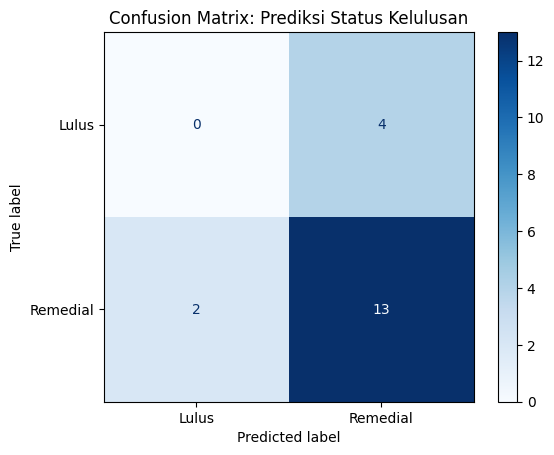

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fitur yang dipakai untuk memprediksi status (Lulus/Remedial)
fitur = ['mata_pelajaran', 'jenis_ujian', 'kelas']
X = pd.get_dummies(df[fitur], drop_first=True)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Prediksi Status Kelulusan')
plt.show()

#Jawaban Analisi Awal

**1. Mata pelajaran apa yang rata-rata nilainya paling rendah?** Dari hasil rata_per_mapel (gambar 4):
- Basis Data: 59.7  (**paling rendah**)
- PKK: 63.3
- KKA: 64.2
- Matematika: 66.7
- Pemrograman Web: 67.3
- Bahasa Inggris: 67.5

Jadi **Basis Data** adalah mata pelajaran dengan rata-rata nilai paling rendah (59.7).

**2. Berapa persentase siswa yang nilainya di bawah KKM (75)?**

Dari output: *"Jumlah siswa remedial: 61 dari 75 (81.3%)"*, Jadi **81.3%** siswa (61 dari 75 siswa) nilainya di bawah KKM.

**3. Apakah ada perbedaan rata-rata nilai antar kelas (XI RPL 1, 2, 3)?**

Dari hasil rata_per_kelas (gambar 4):
- XI RPL 1: 67.1
- XI RPL 2: 67.1
- XI RPL 3: 61.3

**Ya, ada perbedaan.** XI RPL 1 dan XI RPL 2 memiliki rata-rata nilai yang sama (67.1), sedangkan **XI RPL 3 lebih rendah** (61.3) dibanding dua kelas lainnya.

#summary
1. Kualitas data awal buruk: 4 duplikat, teks ada yang menyasar di kolom nilai, outlier 999, tiga format tanggal berbeda, dan penulisan jenis ujian tidak konsisten, setelah dibersihkan tersisa 75 baris siap analisis.
2. Sekitar 81% data ujian masih di bawah KKM (status Remedial). Basis Data rata-rata terendah (±59,7), Bahasa Inggris tertinggi (±67,5), Basis data harus diperhatikan/diteliti lagi
3. XI RPL 3 rata ratanya tertinggal (rata-rata ±61,3) dibandingkan XI RPL 1 dan XI RPL 2 (±67).